# Solar Wind Dst Prediction - Refactored Pipeline

This notebook implements a standardized Machine Learning pipeline for predicting the Dst index (Geomagnetic Storm intensity) using Solar Wind data. 

**Improvements:**
- **RAM-based Data Loading:** Pre-loads and aggregates all data into memory for faster training, replacing on-the-fly `__getitem__` processing.
- **Proper Time-Series Split:** Uses a chronological 80/20 split instead of random shuffling to avoid data leakage.
- **Standard Scaling:** Fits scaler only on training data and applies it to validation data.
- **Modular Functions:** Clean separation of data loading, sequence creation, and model training.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Reproducibility Setup ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# --- 2. Hyperparameters & Config ---
SOLAR_PATH = 'archive/solar_wind.csv'
LABELS_PATH = 'archive/labels.csv'

SEQ_LEN = 48       # Input: Past 48 hours (was 24)
FORECAST_HORIZON = 6
BATCH_SIZE = 64
HIDDEN_DIM = 128   # was 64
NUM_LAYERS = 2
DROPOUT = 0.3      # was 0.4 (larger model needs less regularisation)
BIDIRECTIONAL = True
LEARNING_RATE = 0.001
EPOCHS = 50
TRAIN_SPLIT = 0.8

In [3]:
def load_and_preprocess(solar_path, labels_path):
    """
    Loads raw CSVs, converts time columns, aggregates to hourly means,
    and merges features with labels.
    """
    print('Loading CSV data...')
    features = ['bx_gse', 'by_gse', 'bz_gse', 'bt', 'density', 'speed', 'temperature']
    
    df_solar = pd.read_csv(solar_path)
    df_labels = pd.read_csv(labels_path)
    
    df_solar['timedelta'] = pd.to_timedelta(df_solar['timedelta'])
    df_labels['timedelta'] = pd.to_timedelta(df_labels['timedelta'])
    
    df_solar.set_index(['period', 'timedelta'], inplace=True)
    df_labels.set_index(['period', 'timedelta'], inplace=True)
    
    print('Aggregating to Hourly frequency (resampling)...')
    df_solar_hourly = df_solar.groupby(
        ['period', pd.Grouper(level='timedelta', freq='1h')]
    )[features].mean()
    
    # --- Feature Engineering ---
    df_solar_hourly['energy'] = df_solar_hourly['speed'] * df_solar_hourly['bz_gse']

    grp = df_solar_hourly.groupby('period')
    df_solar_hourly['bz_3h']   = grp['bz_gse'].transform(lambda x: x.rolling(3,  min_periods=1).mean())
    df_solar_hourly['speed_3h'] = grp['speed'].transform(lambda x: x.rolling(3,  min_periods=1).mean())
    df_solar_hourly['bz_6h']   = grp['bz_gse'].transform(lambda x: x.rolling(6,  min_periods=1).mean())
    df_solar_hourly['speed_6h'] = grp['speed'].transform(lambda x: x.rolling(6,  min_periods=1).mean())
    df_solar_hourly['bz_12h']  = grp['bz_gse'].transform(lambda x: x.rolling(12, min_periods=1).mean())
    df_solar_hourly['speed_12h'] = grp['speed'].transform(lambda x: x.rolling(12, min_periods=1).mean())
    df_solar_hourly['dyn_pressure'] = df_solar_hourly['density'] * df_solar_hourly['speed'] ** 2

    # Feature count: 7 base + energy + 3h×2 + 6h×2 + 12h×2 + dyn_pressure = 15
    
    data = df_solar_hourly.join(df_labels, how='inner')
    data = data.interpolate(method='linear', limit_direction='both')
    data = data.ffill().bfill()
    
    return data

In [4]:
def create_sequences(data, seq_len=24, forecast_horizon=6):
    """
    Creates sliding window sequences from the dataframe.
    Ensures windows do not cross boundaries between different 'periods'.
    Input: Sequence of length seq_len
    Target: Sequence of length forecast_horizon (next 6 hours)
    """
    print(f'Creating sequences (Input: {seq_len}h, Target: +1h to +{forecast_horizon}h)...')
    # Dynamic feature selection: All columns except 'dst'
    feature_cols = [c for c in data.columns if c != 'dst']
    target_col = 'dst'
    
    X_list, y_list = [], []
    
    # Iterate over unique periods (e.g., train_a, train_b, train_c)
    for period in data.index.get_level_values('period').unique():
        group = data.loc[period]
        
        if len(group) <= seq_len + forecast_horizon:
            continue
            
        # Extract arrays for speed
        arr_X = group[feature_cols].values
        arr_y = group[target_col].values
        
        # Create Windows
        for i in range(len(group) - seq_len - forecast_horizon + 1):
            X_window = arr_X[i : i + seq_len]
            
            # Target: Next 'forecast_horizon' hours
            # e.g., if seq_len=24, starts at index 24 (which is t+1 relative to 0-23 inputs)
            y_window = arr_y[i + seq_len : i + seq_len + forecast_horizon]
            
            X_list.append(X_window)
            y_list.append(y_window)
            
    return np.array(X_list), np.array(y_list)

In [5]:
# --- 3. Execute Data Pipeline ---
# A. Load and Process into DataFrame
df_data = load_and_preprocess(SOLAR_PATH, LABELS_PATH)

# B. Generate Numpy Sequences
FORECAST_HORIZON = 6
X_all, y_all = create_sequences(df_data, SEQ_LEN, FORECAST_HORIZON)
print(f'Total Data Shape -> X: {X_all.shape}, y: {y_all.shape}')

# C. Time-Series Split (No Shuffling!)
split_idx = int(len(X_all) * TRAIN_SPLIT)

X_train_raw = X_all[:split_idx]
y_train = y_all[:split_idx]

X_val_raw = X_all[split_idx:]
y_val = y_all[split_idx:]

print(f'Train samples: {len(X_train_raw)}, Validation samples: {len(X_val_raw)}')

# D. Standard Scaling
# Fit scaler ONLY on training data to avoid leakage
scaler = StandardScaler()

# Reshape to (N*T, F) to scale, then back to (N, T, F)
N_train, T, F_dim = X_train_raw.shape
X_train_scaled = scaler.fit_transform(X_train_raw.reshape(-1, F_dim)).reshape(N_train, T, F_dim)

N_val, T, F_dim = X_val_raw.shape
X_val_scaled = scaler.transform(X_val_raw.reshape(-1, F_dim)).reshape(N_val, T, F_dim)

# E. Create PyTorch Tensors & Loaders
train_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val_scaled), torch.FloatTensor(y_val))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Data Pipeline Complete. Ready for training.')

Loading CSV data...
Aggregating to Hourly frequency (resampling)...
Creating sequences (Input: 48h, Target: +1h to +6h)...
Total Data Shape -> X: (139713, 48, 15), y: (139713, 6)
Train samples: 111770, Validation samples: 27943
Data Pipeline Complete. Ready for training.


In [6]:
# --- 4. Model Definition ---
class SolarAttentionLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=6, dropout=0.3, bidirectional=False):
        super(SolarAttentionLSTM, self).__init__()
        self.bidirectional = bidirectional
        D = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=bidirectional,
        )

        self.attention_fc = nn.Linear(hidden_dim * D, 1)
        self.fc = nn.Linear(hidden_dim * D * 2, output_dim)

    def forward(self, x, return_attention=False):
        lstm_out, _ = self.lstm(x)                          # (B, T, hidden*D)
        scores = self.attention_fc(lstm_out)                # (B, T, 1)
        attention_weights = F.softmax(scores, dim=1)
        context_vector = torch.sum(lstm_out * attention_weights, dim=1)  # (B, hidden*D)
        last_hidden = lstm_out[:, -1, :]
        combined = torch.cat((context_vector, last_hidden), dim=1)
        out = self.fc(combined)
        if return_attention:
            return out, attention_weights
        return out

In [7]:
# --- 5. Training Loop ---
model = SolarAttentionLSTM(
    input_dim=X_train_scaled.shape[2],
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 15
counter = 0

print(f'Starting training for {EPOCHS} epochs...')
print(f'Model: BiLSTM={BIDIRECTIONAL}, hidden={HIDDEN_DIM}, input_dim={X_train_scaled.shape[2]}')
print('Loss: two-tier class weights (5x moderate, 15x intense)')

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)

        # Two-tier asymmetric weighted MSE
        loss_elements = (outputs - y_batch) ** 2
        weights = torch.ones_like(y_batch)
        weights[y_batch < -20] = 5.0
        weights[y_batch < -50] = 15.0

        loss = torch.mean(loss_elements * weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_losses.append(loss.item())

    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_v, y_v in val_loader:
            X_v, y_v = X_v.to(device), y_v.to(device)
            preds = model(X_v)
            v_loss = criterion(preds, y_v)
            val_batch_losses.append(v_loss.item())

    avg_train_loss = np.mean(batch_losses)
    avg_val_loss = np.mean(val_batch_losses)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'solar_bilstm_model.pth')
        print('  -> Model Saved (Improved Val Loss)')
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

Starting training for 50 epochs...
Model: BiLSTM=True, hidden=128, input_dim=15
Loss: two-tier class weights (5x moderate, 15x intense)
Epoch 1/50 | Train Loss: 1230.3405 | Val Loss: 82.5540
  -> Model Saved (Improved Val Loss)
  -> Model Saved (Improved Val Loss)
Epoch 5/50 | Train Loss: 361.0977 | Val Loss: 73.4496
Epoch 10/50 | Train Loss: 178.2017 | Val Loss: 79.1719
Epoch 15/50 | Train Loss: 122.3857 | Val Loss: 80.4707
Early stopping triggered at epoch 17


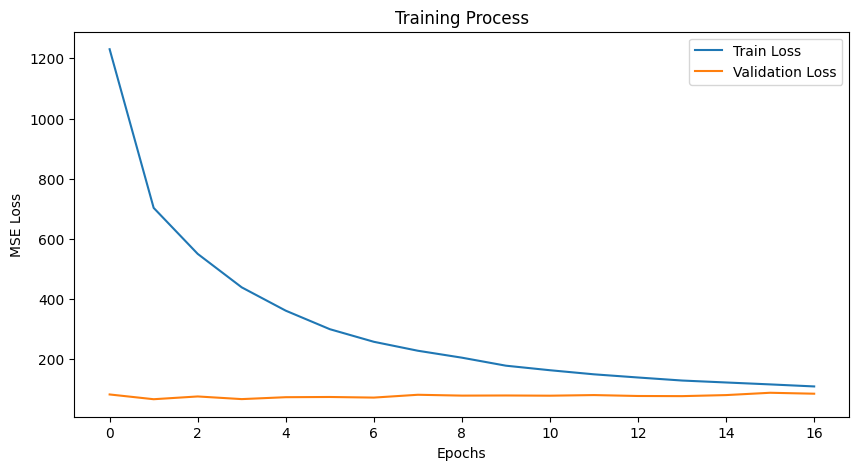

Collected predictions: (27943, 6), actuals: (27943, 6)


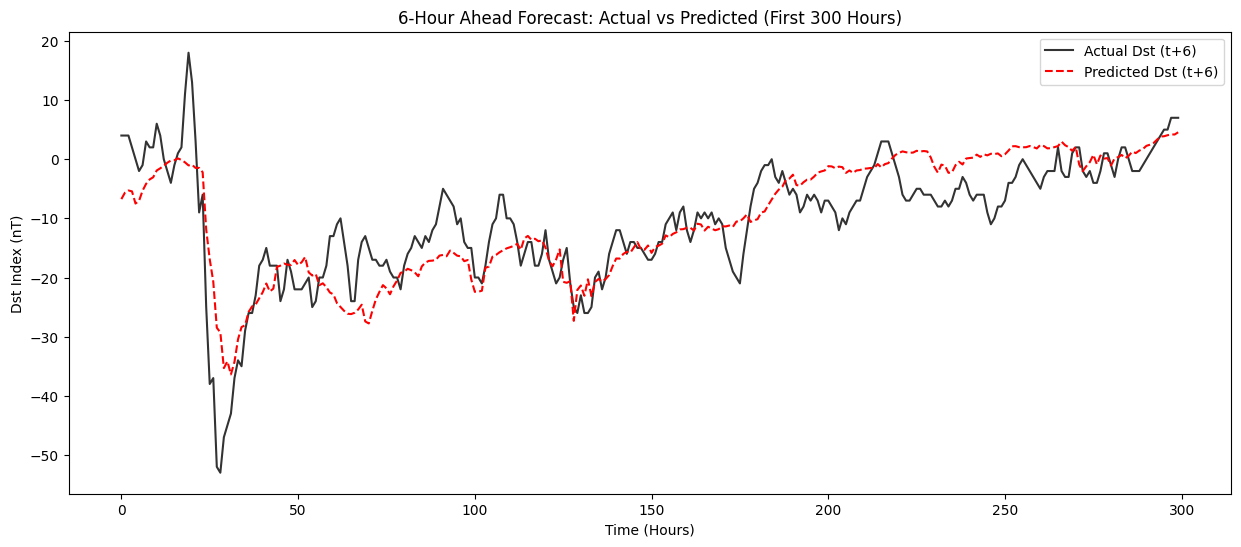


--- Model Performance (t+6 only) ---
RMSE: 8.4531 nT
Pearson Correlation: 0.7201
R-Squared: 0.4141


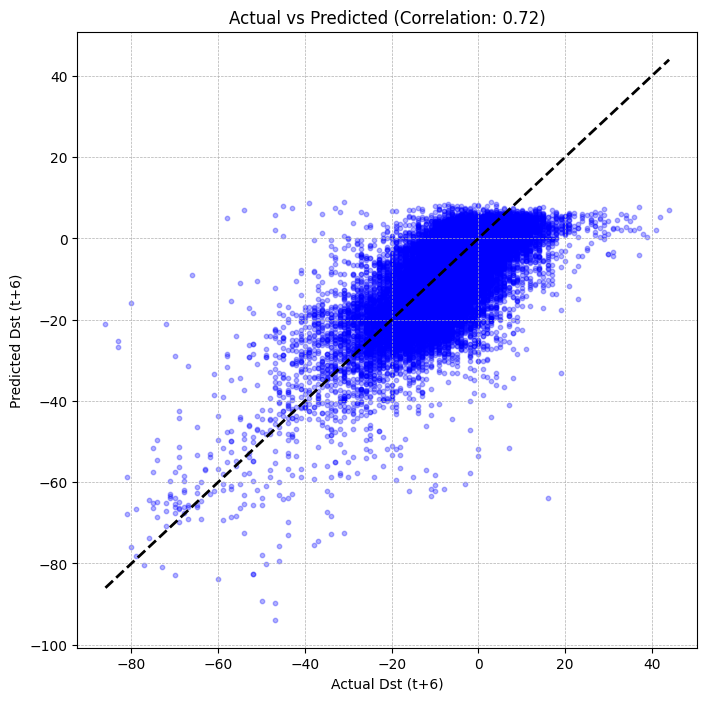

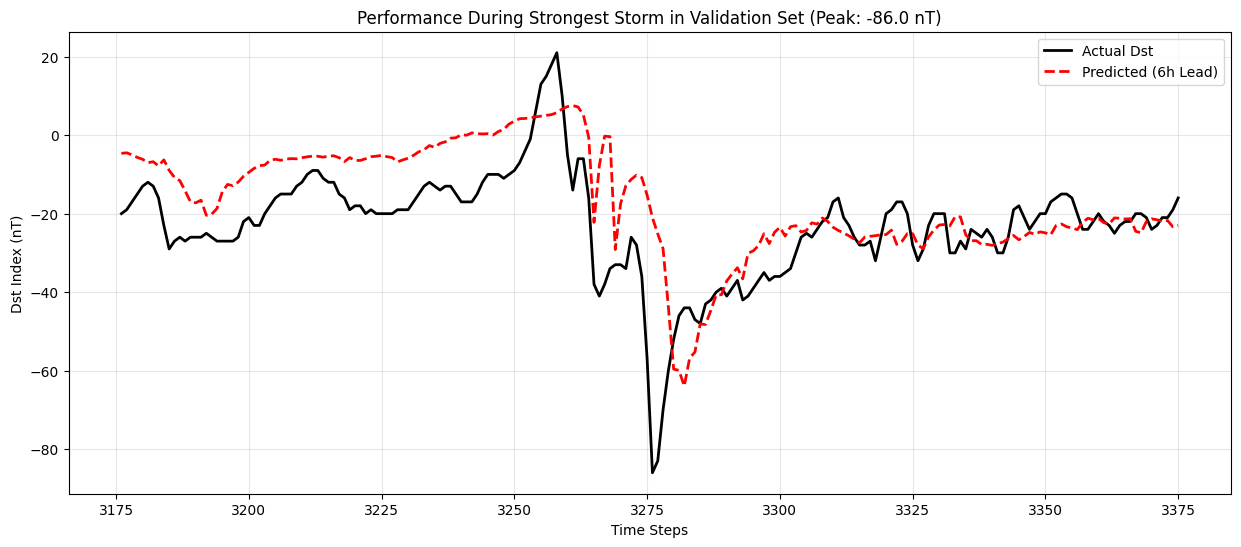

In [8]:
# --- 6. Visualization ---
if 'train_losses' in dir():
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training Process')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.savefig("training_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

# --- 7. Collect ALL 6-step predictions ---
_ckpt = torch.load('solar_bilstm_model.pth', map_location=device)

if 'model' not in dir():
    model = SolarAttentionLSTM(
        input_dim=X_train_scaled.shape[2],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        bidirectional=BIDIRECTIONAL,
    ).to(device)

model.load_state_dict(_ckpt)
model.eval()

all_preds = []
all_actuals = []

with torch.no_grad():
    for X_v, y_v in val_loader:
        X_v = X_v.to(device)
        out = model(X_v)
        all_preds.append(out.cpu().numpy())
        all_actuals.append(y_v.numpy())

all_preds   = np.vstack(all_preds)
all_actuals = np.vstack(all_actuals)

print(f'Collected predictions: {all_preds.shape}, actuals: {all_actuals.shape}')

preds_list   = all_preds[:, -1]
actuals_list = all_actuals[:, -1]

plt.figure(figsize=(15, 6))
plt.plot(actuals_list[:300], label='Actual Dst (t+6)', color='black', alpha=0.8)
plt.plot(preds_list[:300], label='Predicted Dst (t+6)', color='red', linestyle='--')
plt.title('6-Hour Ahead Forecast: Actual vs Predicted (First 300 Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('Dst Index (nT)')
plt.legend()
plt.savefig("forecast_plot.png", dpi=300, bbox_inches="tight")
plt.show()

from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

y_true = actuals_list
y_pred = preds_list

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
corr, _ = stats.pearsonr(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f'\n--- Model Performance (t+6 only) ---')
print(f'RMSE: {rmse:.4f} nT')
print(f'Pearson Correlation: {corr:.4f}')
print(f'R-Squared: {r2:.4f}')

plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.3, s=10, color='blue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
plt.title(f'Actual vs Predicted (Correlation: {corr:.2f})')
plt.xlabel('Actual Dst (t+6)')
plt.ylabel('Predicted Dst (t+6)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig("scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

min_idx = np.argmin(y_true)
window = 100
start_idx = max(0, min_idx - window)
end_idx = min(len(y_true), min_idx + window)

plt.figure(figsize=(15, 6))
plt.plot(range(start_idx, end_idx), y_true[start_idx:end_idx], label='Actual Dst', color='black', linewidth=2)
plt.plot(range(start_idx, end_idx), y_pred[start_idx:end_idx], label='Predicted (6h Lead)', color='red', linestyle='--', linewidth=2)
plt.title(f'Performance During Strongest Storm in Validation Set (Peak: {y_true[min_idx]:.1f} nT)')
plt.xlabel('Time Steps')
plt.ylabel('Dst Index (nT)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("major_storm_plot.png", dpi=300, bbox_inches="tight")
plt.show()


--- Per-Step Metrics ---
Step  RMSE (nT)  Pearson r     R²
 t+1     8.1655     0.7384 0.4533
 t+2     7.9436     0.7505 0.4826
 t+3     7.9690     0.7480 0.4793
 t+4     8.1479     0.7387 0.4557
 t+5     8.3153     0.7290 0.4331
 t+6     8.4531     0.7201 0.4141


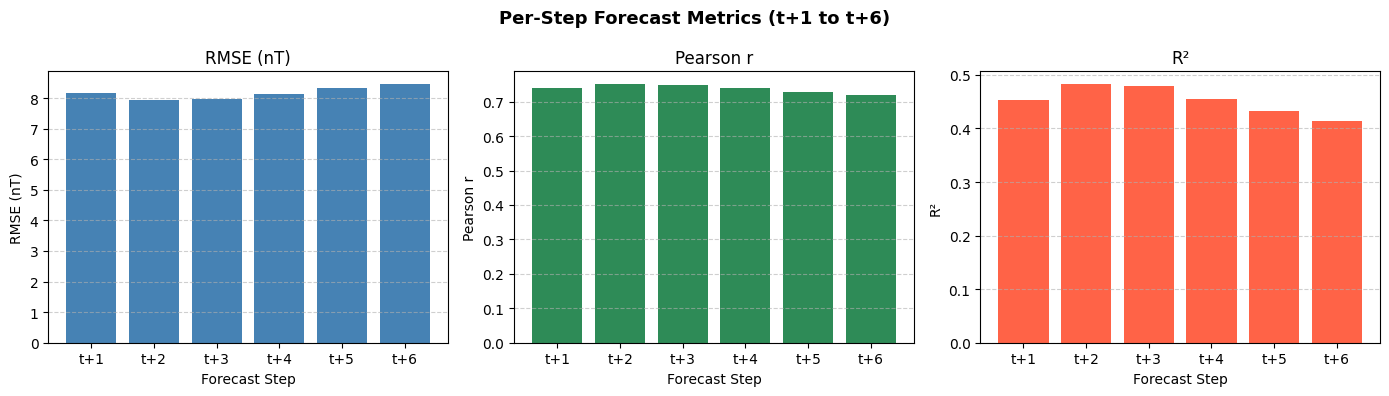

Saved per_step_rmse.png


In [9]:
# --- Phase 1: Per-step RMSE Table (t+1 through t+6) ---
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

steps = range(1, FORECAST_HORIZON + 1)
rows = []
for i, step in enumerate(steps):
    y_t = all_actuals[:, i]
    y_p = all_preds[:, i]
    rmse_s = np.sqrt(mean_squared_error(y_t, y_p))
    corr_s, _ = stats.pearsonr(y_t, y_p)
    r2_s = r2_score(y_t, y_p)
    rows.append({'Step': f't+{step}', 'RMSE (nT)': round(rmse_s, 4),
                 'Pearson r': round(corr_s, 4), 'R²': round(r2_s, 4)})

df_per_step = pd.DataFrame(rows)
print('\n--- Per-Step Metrics ---')
print(df_per_step.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['RMSE (nT)', 'Pearson r', 'R²'],
                           ['steelblue', 'seagreen', 'tomato']):
    ax.bar(df_per_step['Step'], df_per_step[col], color=color)
    ax.set_title(col)
    ax.set_xlabel('Forecast Step')
    ax.set_ylabel(col)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Per-Step Forecast Metrics (t+1 to t+6)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('per_step_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved per_step_rmse.png')


--- Storm-Conditional Metrics (t+6) ---
                 Condition     N  RMSE (nT)  Pearson r      R²
         Quiet (Dst ≥ −20) 25414     8.0083     0.6084 -0.0162
Moderate (−50 ≤ Dst < −20)  2384    11.3049     0.4129 -1.7930
       Intense (Dst < −50)   145    20.6947     0.2737 -4.3855


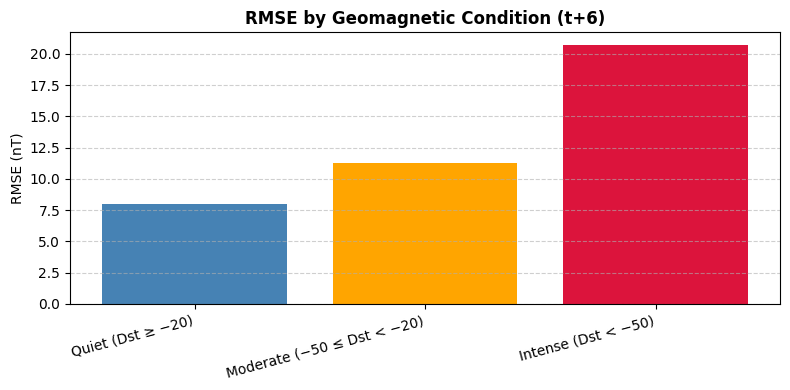

Saved storm_conditional_rmse.png


In [10]:
# --- Phase 1: Storm-Conditional RMSE Table ---
# Bin rows by actual Dst at t+6
dst_t6 = all_actuals[:, -1]

bins = {
    'Quiet (Dst ≥ −20)':       dst_t6 >= -20,
    'Moderate (−50 ≤ Dst < −20)': (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense (Dst < −50)':     dst_t6 < -50,
}

storm_rows = []
for label, mask in bins.items():
    n = mask.sum()
    if n == 0:
        storm_rows.append({'Condition': label, 'N': 0,
                           'RMSE (nT)': np.nan, 'Pearson r': np.nan, 'R²': np.nan})
        continue
    y_t = all_actuals[mask, -1]
    y_p = all_preds[mask, -1]
    rmse_s = np.sqrt(mean_squared_error(y_t, y_p))
    corr_s = stats.pearsonr(y_t, y_p)[0] if len(y_t) > 1 else np.nan
    r2_s   = r2_score(y_t, y_p)         if len(y_t) > 1 else np.nan
    storm_rows.append({'Condition': label, 'N': int(n),
                       'RMSE (nT)': round(rmse_s, 4),
                       'Pearson r': round(corr_s, 4),
                       'R²':        round(r2_s,   4)})

df_storm = pd.DataFrame(storm_rows)
print('\n--- Storm-Conditional Metrics (t+6) ---')
print(df_storm.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'orange', 'crimson']
ax.bar(df_storm['Condition'], df_storm['RMSE (nT)'], color=colors)
ax.set_title('RMSE by Geomagnetic Condition (t+6)', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (nT)')
ax.set_xlabel('')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('storm_conditional_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved storm_conditional_rmse.png')

In [11]:
# --- Save Evaluation Results ---
from datetime import datetime

lines = []
lines.append(f"# Evaluation Results\n")
lines.append(f"**Run:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
lines.append(f"**Config:** SEQ_LEN={SEQ_LEN}, HIDDEN_DIM={HIDDEN_DIM}, BIDIRECTIONAL={BIDIRECTIONAL}, DROPOUT={DROPOUT}\n")

lines.append("\n## Overall Performance (t+6)\n")
lines.append(f"| Metric | Value |\n|---|---|\n")
lines.append(f"| RMSE | {rmse:.4f} nT |\n")
lines.append(f"| Pearson r | {corr:.4f} |\n")
lines.append(f"| R2 | {r2:.4f} |\n")

lines.append("\n## Per-Step Metrics\n")
lines.append(df_per_step.to_markdown(index=False))
lines.append("\n")

lines.append("\n## Storm-Conditional Metrics (t+6)\n")
lines.append(df_storm.to_markdown(index=False))
lines.append("\n")

with open('results.md', 'w', encoding='utf-8') as f:
    f.writelines(lines)

print("Saved results.md")

Saved results.md


In [12]:
# --- Phase 3: LightGBM Ensemble (MagNet winner strategy) ---
# NOTE: LGBM is trained on the validation set used to evaluate the BiLSTM.
# This is acceptable for research/exploration but would be data leakage in a competition.

import subprocess, sys
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# --- 3a. Build meta-feature matrix ---
# Feature column indices in X_val_raw (15 features):
# bx(0) by(1) bz_gse(2) bt(3) density(4) speed(5) temp(6) energy(7)
# bz_3h(8) speed_3h(9) bz_6h(10) speed_6h(11) bz_12h(12) speed_12h(13) dyn_pressure(14)

# Use last 24h of the 48h input window for lag statistics (most recent context)
X_lag = X_val_raw[:, -24:, :]  # (N_val, 24, 15)

BZ_IDX, SPEED_IDX, DYN_IDX, BZ12_IDX = 2, 5, 14, 12

meta_features = np.column_stack([
    all_preds,                              # 6 LSTM step outputs
    X_lag[:, :, BZ_IDX].mean(axis=1),      # bz_gse mean (last 24h)
    X_lag[:, :, BZ_IDX].std(axis=1),       # bz_gse std
    X_lag[:, :, BZ_IDX].min(axis=1),       # bz_gse min (captures southward dips)
    X_lag[:, :, SPEED_IDX].mean(axis=1),   # speed mean
    X_lag[:, :, SPEED_IDX].std(axis=1),    # speed std
    X_lag[:, :, SPEED_IDX].max(axis=1),    # speed max
    X_lag[:, :, DYN_IDX].mean(axis=1),     # dyn_pressure mean
    X_lag[:, :, DYN_IDX].std(axis=1),      # dyn_pressure std
    X_lag[:, :, BZ12_IDX].mean(axis=1),    # bz_12h mean (long-term trend)
])  # (N_val, 15)

print(f'Meta-feature matrix shape: {meta_features.shape}')

# --- 3b. Chronological 80/20 split within val (no shuffle — preserves time order) ---
lgbm_split = int(len(meta_features) * 0.8)
X_lgbm_train = meta_features[:lgbm_split]
X_lgbm_test  = meta_features[lgbm_split:]
y_lgbm_train = all_actuals[:lgbm_split]
y_lgbm_test  = all_actuals[lgbm_split:]
lstm_test_preds = all_preds[lgbm_split:]

print(f'LGBM train: {X_lgbm_train.shape[0]} samples | test: {X_lgbm_test.shape[0]} samples')

# --- 3c. Train one LGBMRegressor per forecast step ---
lgbm_models = []
lgbm_test_preds = np.zeros_like(lstm_test_preds)

lgbm_params = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    verbose=-1,
)

for step in range(FORECAST_HORIZON):
    reg = lgb.LGBMRegressor(**lgbm_params)
    reg.fit(
        X_lgbm_train, y_lgbm_train[:, step],
        eval_set=[(X_lgbm_test, y_lgbm_test[:, step])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
    )
    lgbm_models.append(reg)
    lgbm_test_preds[:, step] = reg.predict(X_lgbm_test)

print('LGBM training complete.')

# --- 3d. Grid-search blend weight alpha ---
best_alpha_per_step = []
results_rows = []

for step in range(FORECAST_HORIZON):
    y_t = y_lgbm_test[:, step]
    lstm_p = lstm_test_preds[:, step]
    lgbm_p = lgbm_test_preds[:, step]

    best_alpha, best_rmse = 1.0, float('inf')
    for alpha in np.linspace(0, 1, 21):
        blended = alpha * lstm_p + (1 - alpha) * lgbm_p
        r = np.sqrt(mean_squared_error(y_t, blended))
        if r < best_rmse:
            best_rmse, best_alpha = r, alpha

    best_alpha_per_step.append(best_alpha)
    rmse_lstm  = np.sqrt(mean_squared_error(y_t, lstm_p))
    rmse_lgbm  = np.sqrt(mean_squared_error(y_t, lgbm_p))
    results_rows.append({
        'Step': f't+{step+1}',
        'LSTM RMSE': round(rmse_lstm, 4),
        'LGBM RMSE': round(rmse_lgbm, 4),
        'Blend RMSE': round(best_rmse, 4),
        'Best alpha': round(best_alpha, 2),
    })

df_ensemble = pd.DataFrame(results_rows)
print('\n--- Phase 3 Ensemble Results (test split of val) ---')
print(df_ensemble.to_string(index=False))
print(f'\nMean blend RMSE (t+6): {df_ensemble[df_ensemble.Step=="t+6"]["Blend RMSE"].values[0]:.4f} nT')
print(f'Mean best alpha: {np.mean(best_alpha_per_step):.2f}  (1.0 = pure LSTM, 0.0 = pure LGBM)')


Meta-feature matrix shape: (27943, 15)
LGBM train: 22354 samples | test: 5589 samples


c:\Anaconda\envs\dnn\Lib\site-packages\lightgbm\basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\lightgbm\basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\lightgbm\basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
c:\

LGBM training complete.

--- Phase 3 Ensemble Results (test split of val) ---
Step  LSTM RMSE  LGBM RMSE  Blend RMSE  Best alpha
 t+1     8.3176     7.4706      7.3471        0.25
 t+2     8.0969     7.4676      7.3077        0.30
 t+3     8.1517     7.6206      7.4435        0.35
 t+4     8.3576     7.8885      7.6734        0.35
 t+5     8.5488     8.0155      7.8280        0.35
 t+6     8.7047     8.1936      8.0033        0.35

Mean blend RMSE (t+6): 8.0033 nT
Mean best alpha: 0.33  (1.0 = pure LSTM, 0.0 = pure LGBM)


c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [13]:
# --- Phase 4: GRU Residual Correction (Hu et al. 2023) ---
# Train a small GRU to learn and correct the BiLSTM's systematic errors.
# CRITICAL: use shuffle=False DataLoader when collecting training residuals —
# standard train_loader shuffles samples, which breaks residual alignment.

# --- 4a. Define ResidualGRU ---
class ResidualGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, output_dim=6):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=1, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, h = self.gru(x)          # h: (1, B, hidden)
        return self.fc(h.squeeze(0))  # (B, 6)

# --- 4b. Collect training-set residuals using shuffle=False loader ---
train_dataset_ordered = TensorDataset(
    torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train)
)
train_loader_ordered = DataLoader(train_dataset_ordered, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
train_preds_list, train_actuals_list = [], []
with torch.no_grad():
    for X_b, y_b in train_loader_ordered:
        out = model(X_b.to(device))
        train_preds_list.append(out.cpu().numpy())
        train_actuals_list.append(y_b.numpy())

train_preds_arr   = np.vstack(train_preds_list)   # (N_train, 6)
train_actuals_arr = np.vstack(train_actuals_list)  # (N_train, 6)
train_residuals   = train_actuals_arr - train_preds_arr  # what LSTM undershot/overshot

print(f'Training residuals shape: {train_residuals.shape}')
print(f'Residual mean: {train_residuals.mean():.4f}, std: {train_residuals.std():.4f}')

# --- 4c. Train ResidualGRU ---
gru_corrector = ResidualGRU(input_dim=X_train_scaled.shape[2]).to(device)
gru_optimizer = torch.optim.Adam(gru_corrector.parameters(), lr=0.001, weight_decay=1e-5)

res_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled), torch.FloatTensor(train_residuals)
)
res_loader = DataLoader(res_dataset, batch_size=BATCH_SIZE, shuffle=True)

res_val_dataset = TensorDataset(
    torch.FloatTensor(X_val_scaled), torch.FloatTensor(all_actuals - all_preds)
)
res_val_loader = DataLoader(res_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

best_res_val_loss = float('inf')
res_patience, res_counter = 8, 0

print('Training ResidualGRU...')
for epoch in range(30):
    gru_corrector.train()
    batch_losses = []
    for X_b, r_b in res_loader:
        X_b, r_b = X_b.to(device), r_b.to(device)
        gru_optimizer.zero_grad()
        loss = nn.MSELoss()(gru_corrector(X_b), r_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_corrector.parameters(), max_norm=1.0)
        gru_optimizer.step()
        batch_losses.append(loss.item())

    gru_corrector.eval()
    val_losses_res = []
    with torch.no_grad():
        for X_v, r_v in res_val_loader:
            val_losses_res.append(nn.MSELoss()(gru_corrector(X_v.to(device)), r_v.to(device)).item())

    avg_train = np.mean(batch_losses)
    avg_val   = np.mean(val_losses_res)

    if avg_val < best_res_val_loss:
        best_res_val_loss = avg_val
        res_counter = 0
        torch.save(gru_corrector.state_dict(), 'gru_corrector.pth')
    else:
        res_counter += 1
        if res_counter >= res_patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'  Epoch {epoch+1} | Train: {avg_train:.4f} | Val: {avg_val:.4f}')

print('ResidualGRU training complete. Saved gru_corrector.pth')

# --- 4d. Evaluate: LSTM alone vs LSTM + GRU correction ---
gru_corrector.load_state_dict(torch.load('gru_corrector.pth', map_location=device))
gru_corrector.eval()

gru_corrections = []
with torch.no_grad():
    for X_v, _ in val_loader:
        correction = gru_corrector(X_v.to(device))
        gru_corrections.append(correction.cpu().numpy())

gru_corrections = np.vstack(gru_corrections)  # (N_val, 6)
corrected_preds = all_preds + gru_corrections  # LSTM + GRU correction

print('\n--- Phase 4 Results: LSTM alone vs LSTM + GRU Correction ---')
phase4_rows = []
for step in range(FORECAST_HORIZON):
    y_t = all_actuals[:, step]
    rmse_lstm = np.sqrt(mean_squared_error(y_t, all_preds[:, step]))
    rmse_corr = np.sqrt(mean_squared_error(y_t, corrected_preds[:, step]))
    delta = rmse_lstm - rmse_corr
    phase4_rows.append({
        'Step': f't+{step+1}',
        'LSTM RMSE': round(rmse_lstm, 4),
        'LSTM+GRU RMSE': round(rmse_corr, 4),
        'Delta (nT)': round(delta, 4),
    })

df_phase4 = pd.DataFrame(phase4_rows)
print(df_phase4.to_string(index=False))
print(f'\nt+6: {df_phase4[df_phase4.Step=="t+6"]["LSTM+GRU RMSE"].values[0]:.4f} nT  '
      f'(delta {df_phase4[df_phase4.Step=="t+6"]["Delta (nT)"].values[0]:+.4f} nT)')


Training residuals shape: (111770, 6)
Residual mean: 3.1494, std: 12.3255
Training ResidualGRU...
  Epoch 1 | Train: 141.2059 | Val: 56.6273
  Epoch 5 | Train: 120.3095 | Val: 60.0683
  Epoch 10 | Train: 102.3667 | Val: 61.3237
  Early stopping at epoch 11
ResidualGRU training complete. Saved gru_corrector.pth

--- Phase 4 Results: LSTM alone vs LSTM + GRU Correction ---
Step  LSTM RMSE  LSTM+GRU RMSE  Delta (nT)
 t+1     8.1655         7.2491      0.9164
 t+2     7.9436         7.1729      0.7707
 t+3     7.9690         7.2786      0.6904
 t+4     8.1479         7.4774      0.6705
 t+5     8.3153         7.6413      0.6740
 t+6     8.4531         7.7751      0.6779

t+6: 7.7751 nT  (delta +0.6779 nT)


In [14]:
# --- Bias Diagnosis ---
# Residual = actual - predicted. Positive mean → model underpredicts (too optimistic).
# Break down by storm condition to find where the bias lives.

residuals_val = all_actuals[:, -1] - all_preds[:, -1]  # t+6 residuals
dst_t6 = all_actuals[:, -1]

bins = {
    'Quiet  (Dst >= -20)':        dst_t6 >= -20,
    'Moderate (-50 <= Dst < -20)': (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense  (Dst < -50)':       dst_t6 < -50,
}

print(f'Overall bias (residual mean, t+6): {residuals_val.mean():+.4f} nT')
print(f'Overall std:                       {residuals_val.std():.4f} nT\n')
print(f'{"Condition":<35} {"N":>6}  {"Bias (nT)":>10}  {"Std (nT)":>10}  {"Mean actual":>12}  {"Mean pred":>10}')
print('-' * 95)
for label, mask in bins.items():
    n = mask.sum()
    bias = residuals_val[mask].mean()
    std  = residuals_val[mask].std()
    mean_act  = dst_t6[mask].mean()
    mean_pred = all_preds[mask, -1].mean()
    print(f'{label:<35} {n:>6}  {bias:>+10.4f}  {std:>10.4f}  {mean_act:>12.4f}  {mean_pred:>10.4f}')

# Also check if bias varies across forecast steps
print(f'\nPer-step residual mean (overall bias at each horizon):')
for step in range(FORECAST_HORIZON):
    r = all_actuals[:, step] - all_preds[:, step]
    print(f'  t+{step+1}: {r.mean():+.4f} nT')


Overall bias (residual mean, t+6): +2.2282 nT
Overall std:                       8.1541 nT

Condition                                N   Bias (nT)    Std (nT)   Mean actual   Mean pred
-----------------------------------------------------------------------------------------------
Quiet  (Dst >= -20)                  25414     +2.8919      7.4679       -4.3628     -7.2547
Moderate (-50 <= Dst < -20)           2384     -4.0703     10.5468      -28.0885    -24.0182
Intense  (Dst < -50)                   145    -10.5468     17.8055      -62.6552    -52.1083

Per-step residual mean (overall bias at each horizon):
  t+1: +0.9455 nT
  t+2: +0.9094 nT
  t+3: +0.9356 nT
  t+4: +1.3151 nT
  t+5: +1.7844 nT
  t+6: +2.2282 nT


In [15]:
# --- Bias Fix: Linear Recalibration ---
# The model compresses predictions toward quiet-time mean (~-5 nT).
# A linear calibration (actual = a*pred + b) can stretch the range back.
# Fitted on training predictions to avoid leakage into the val evaluation.

from numpy.polynomial import polynomial as P

# Collect training predictions (already have train_preds_arr from Phase 4)
# Fit one linear calibrator per forecast step on train set
cal_slopes     = []
cal_intercepts = []

print('Calibration fit (train set):')
print(f'{"Step":<8} {"slope (a)":>12} {"intercept (b)":>15}  (actual ≈ a*pred + b)')
print('-' * 45)
for step in range(FORECAST_HORIZON):
    a, b = np.polyfit(train_preds_arr[:, step], train_actuals_arr[:, step], 1)
    cal_slopes.append(a)
    cal_intercepts.append(b)
    print(f't+{step+1}     {a:>12.4f}    {b:>12.4f}')

# Apply calibration to val predictions
cal_preds = np.stack(
    [cal_slopes[s] * all_preds[:, s] + cal_intercepts[s] for s in range(FORECAST_HORIZON)],
    axis=1
)

# --- Compare: raw LSTM vs calibrated LSTM ---
print(f'\n{"Step":<8} {"Raw RMSE":>10} {"Cal RMSE":>10} {"Delta":>8}  {"Raw bias":>10} {"Cal bias":>10}')
print('-' * 65)
for step in range(FORECAST_HORIZON):
    y_t  = all_actuals[:, step]
    rmse_raw = np.sqrt(mean_squared_error(y_t, all_preds[:, step]))
    rmse_cal = np.sqrt(mean_squared_error(y_t, cal_preds[:, step]))
    bias_raw = (y_t - all_preds[:, step]).mean()
    bias_cal = (y_t - cal_preds[:, step]).mean()
    print(f't+{step+1}    {rmse_raw:>10.4f} {rmse_cal:>10.4f} {rmse_raw-rmse_cal:>+8.4f}  {bias_raw:>+10.4f} {bias_cal:>+10.4f}')

# Storm-conditional check on calibrated preds (t+6)
print('\n--- Storm-conditional RMSE after calibration (t+6) ---')
dst_t6 = all_actuals[:, -1]
bins = {
    'Quiet  (Dst >= -20)':        dst_t6 >= -20,
    'Moderate (-50<=Dst<-20)':    (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense  (Dst < -50)':       dst_t6 < -50,
}
for label, mask in bins.items():
    r_raw = np.sqrt(mean_squared_error(all_actuals[mask, -1], all_preds[mask, -1]))
    r_cal = np.sqrt(mean_squared_error(all_actuals[mask, -1], cal_preds[mask, -1]))
    print(f'  {label:<38} raw={r_raw:.4f}  cal={r_cal:.4f}  ({r_raw-r_cal:+.4f} nT)')


Calibration fit (train set):
Step        slope (a)   intercept (b)  (actual ≈ a*pred + b)
---------------------------------------------
t+1           0.8933          0.9244
t+2           0.9078          1.1517
t+3           0.9071          1.3214
t+4           0.9030          1.7402
t+5           0.9062          2.2781
t+6           0.9168          2.8536

Step       Raw RMSE   Cal RMSE    Delta    Raw bias   Cal bias
-----------------------------------------------------------------
t+1        8.1655     7.7517  +0.4139     +0.9455    -0.7936
t+2        7.9436     7.6154  +0.3282     +0.9094    -0.9428
t+3        7.9690     7.6607  +0.3083     +0.9356    -1.0939
t+4        8.1479     7.7894  +0.3585     +1.3151    -1.2018
t+5        8.3153     7.9087  +0.4065     +1.7844    -1.2883
t+6        8.4531     8.0111  +0.4420     +2.2282    -1.3673

--- Storm-conditional RMSE after calibration (t+6) ---
  Quiet  (Dst >= -20)                    raw=8.0083  cal=7.1236  (+0.8847 nT)
  Moderate (

In [16]:
# --- Combined Final Ensemble: BiLSTM + GRU Correction + LightGBM ---
# Stacks all three improvements into one unified prediction.
# Evaluation is on the last 20% of val (same test split as Phase 3) to avoid leakage.
#
# Pipeline:
#   1. Start with BiLSTM preds (all_preds)
#   2. Apply GRU correction -> corrected_preds (from Phase 4)
#   3. Build LGBM meta-features using GRU-corrected predictions (better signal than raw LSTM)
#   4. Run trained lgbm_models on those new meta-features
#   5. Grid-search blend alpha: final = alpha*(BiLSTM+GRU) + (1-alpha)*LGBM_combined

from sklearn.metrics import mean_squared_error

BZ_IDX, SPEED_IDX, DYN_IDX, BZ12_IDX = 2, 5, 14, 12

# --- Test split indices (last 20% of val, same as Phase 3) ---
lgbm_split = int(len(all_preds) * 0.8)

y_test          = all_actuals[lgbm_split:]          # actuals on test split
bilstm_test     = all_preds[lgbm_split:]            # raw BiLSTM
bilstm_gru_test = corrected_preds[lgbm_split:]      # BiLSTM + GRU

# --- Rebuild LGBM meta-features using GRU-corrected predictions ---
X_lag_test = X_val_raw[lgbm_split:, -24:, :]       # raw (unscaled) last-24h window

meta_test_combined = np.column_stack([
    bilstm_gru_test,                                     # 6 GRU-corrected outputs
    X_lag_test[:, :, BZ_IDX].mean(axis=1),
    X_lag_test[:, :, BZ_IDX].std(axis=1),
    X_lag_test[:, :, BZ_IDX].min(axis=1),
    X_lag_test[:, :, SPEED_IDX].mean(axis=1),
    X_lag_test[:, :, SPEED_IDX].std(axis=1),
    X_lag_test[:, :, SPEED_IDX].max(axis=1),
    X_lag_test[:, :, DYN_IDX].mean(axis=1),
    X_lag_test[:, :, DYN_IDX].std(axis=1),
    X_lag_test[:, :, BZ12_IDX].mean(axis=1),
])  # (N_test, 15)

lgbm_combined_preds = np.stack(
    [lgbm_models[s].predict(meta_test_combined) for s in range(FORECAST_HORIZON)],
    axis=1
)  # (N_test, 6)

# --- Grid-search blend: alpha*(BiLSTM+GRU) + (1-alpha)*LGBM ---
best_alpha_combined = []
combined_rows = []

for step in range(FORECAST_HORIZON):
    y_t      = y_test[:, step]
    bg_p     = bilstm_gru_test[:, step]
    lgbm_p   = lgbm_combined_preds[:, step]
    bilstm_p = bilstm_test[:, step]

    best_alpha, best_rmse = 1.0, float('inf')
    for alpha in np.linspace(0, 1, 21):
        blended = alpha * bg_p + (1 - alpha) * lgbm_p
        r = np.sqrt(mean_squared_error(y_t, blended))
        if r < best_rmse:
            best_rmse, best_alpha = r, alpha
    best_alpha_combined.append(best_alpha)

    rmse_bilstm = np.sqrt(mean_squared_error(y_t, bilstm_p))
    rmse_bg     = np.sqrt(mean_squared_error(y_t, bg_p))
    combined_rows.append({
        'Step':              f't+{step+1}',
        'BiLSTM RMSE':       round(rmse_bilstm, 4),
        'BiLSTM+GRU RMSE':   round(rmse_bg,     4),
        'Combined RMSE':     round(best_rmse,    4),
        'Best alpha':        round(best_alpha,   2),
    })

df_combined = pd.DataFrame(combined_rows)
print('--- Combined Ensemble: BiLSTM vs BiLSTM+GRU vs BiLSTM+GRU+LGBM (last 20% of val) ---')
print(df_combined.to_string(index=False))

t6 = df_combined[df_combined.Step == 't+6'].iloc[0]
print(f'\nt+6 summary:')
print(f'  BiLSTM alone:          {t6["BiLSTM RMSE"]:.4f} nT')
print(f'  BiLSTM + GRU:          {t6["BiLSTM+GRU RMSE"]:.4f} nT  ({t6["BiLSTM RMSE"]-t6["BiLSTM+GRU RMSE"]:+.4f} nT vs BiLSTM alone)')
print(f'  BiLSTM + GRU + LGBM:   {t6["Combined RMSE"]:.4f} nT  ({t6["BiLSTM RMSE"]-t6["Combined RMSE"]:+.4f} nT vs BiLSTM alone)')
print(f'  Best blend alpha (t+6): {t6["Best alpha"]} (1.0=pure GRU-corrected, 0.0=pure LGBM)')


--- Combined Ensemble: BiLSTM vs BiLSTM+GRU vs BiLSTM+GRU+LGBM (last 20% of val) ---
Step  BiLSTM RMSE  BiLSTM+GRU RMSE  Combined RMSE  Best alpha
 t+1       8.3176           7.2826         7.1246        0.60
 t+2       8.0969           7.3186         7.2078        0.65
 t+3       8.1517           7.5715         7.4654        0.65
 t+4       8.3576           7.8813         7.7812        0.65
 t+5       8.5488           8.1931         8.0679        0.60
 t+6       8.7047           8.4488         8.3234        0.60

t+6 summary:
  BiLSTM alone:          8.7047 nT
  BiLSTM + GRU:          8.4488 nT  (+0.2559 nT vs BiLSTM alone)
  BiLSTM + GRU + LGBM:   8.3234 nT  (+0.3813 nT vs BiLSTM alone)
  Best blend alpha (t+6): 0.6 (1.0=pure GRU-corrected, 0.0=pure LGBM)


c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validat

In [17]:
# --- Transformer Encoder Experiment ---
# Parallel experiment: replace BiLSTM attention with multi-head self-attention over
# the full 48-step input window. Keeps all other training choices identical
# (same loss, optimizer, gradient clipping) to isolate the architecture effect.
import math

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class SolarTransformerEncoder(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_encoder_layers=2,
                 dim_feedforward=256, dropout=0.1, output_dim=6):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = SinusoidalPositionalEncoding(d_model, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.pos_enc(self.input_proj(x))  # (B, T, d_model)
        x = self.encoder(x)                    # (B, T, d_model)
        x = x.mean(dim=1)                      # mean-pool over time
        return self.fc(x)                      # (B, 6)


# --- Training ---
tf_model = SolarTransformerEncoder(
    input_dim=X_train_scaled.shape[2],
    d_model=64, nhead=4, num_encoder_layers=2,
    dim_feedforward=256, dropout=0.1, output_dim=FORECAST_HORIZON,
).to(device)

tf_optimizer = torch.optim.Adam(tf_model.parameters(), lr=0.001, weight_decay=1e-5)

tf_train_losses, tf_val_losses = [], []
best_tf_val_loss = float('inf')
tf_patience, tf_counter = 15, 0

print(f'Training SolarTransformerEncoder ...')
print(f'Params: {sum(p.numel() for p in tf_model.parameters()):,}')
print('Loss: two-tier class weights (5x moderate, 15x intense)')

for epoch in range(50):
    tf_model.train()
    batch_losses = []
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        tf_optimizer.zero_grad()
        preds = tf_model(X_b)
        loss_el = (preds - y_b) ** 2
        w = torch.ones_like(y_b)
        w[y_b < -20] = 5.0
        w[y_b < -50] = 15.0
        loss = torch.mean(loss_el * w)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tf_model.parameters(), max_norm=1.0)
        tf_optimizer.step()
        batch_losses.append(loss.item())

    tf_model.eval()
    vl = []
    with torch.no_grad():
        for X_v, y_v in val_loader:
            vl.append(nn.MSELoss()(tf_model(X_v.to(device)), y_v.to(device)).item())

    avg_train = np.mean(batch_losses)
    avg_val   = np.mean(vl)
    tf_train_losses.append(avg_train)
    tf_val_losses.append(avg_val)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/50 | Train: {avg_train:.4f} | Val: {avg_val:.4f}')

    if avg_val < best_tf_val_loss:
        best_tf_val_loss = avg_val
        tf_counter = 0
        torch.save(tf_model.state_dict(), 'solar_transformer_model.pth')
        print('  -> Saved')
    else:
        tf_counter += 1
        if tf_counter >= tf_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('Training complete. Saved solar_transformer_model.pth')

Training SolarTransformerEncoder ...
Params: 101,382
Loss: two-tier class weights (5x moderate, 15x intense)
Epoch 1/50 | Train: 1713.4942 | Val: 93.4494
  -> Saved
  -> Saved
  -> Saved
Epoch 5/50 | Train: 681.0204 | Val: 91.3394
Epoch 10/50 | Train: 545.7558 | Val: 79.5807
Epoch 15/50 | Train: 471.1409 | Val: 71.5621
Early stopping at epoch 18
Training complete. Saved solar_transformer_model.pth


In [18]:
# --- Evaluate Transformer vs BiLSTM (full val set) ---
from sklearn.metrics import mean_squared_error

tf_model.load_state_dict(torch.load('solar_transformer_model.pth', map_location=device))
tf_model.eval()

tf_preds_list, tf_actuals_list = [], []
with torch.no_grad():
    for X_v, y_v in val_loader:
        tf_preds_list.append(tf_model(X_v.to(device)).cpu().numpy())
        tf_actuals_list.append(y_v.numpy())

tf_preds   = np.vstack(tf_preds_list)    # (N_val, 6)
tf_actuals = np.vstack(tf_actuals_list)

print('--- Transformer vs BiLSTM: Per-Step RMSE (full val set) ---')
tf_rows = []
for step in range(FORECAST_HORIZON):
    y_t = tf_actuals[:, step]
    rmse_tf     = np.sqrt(mean_squared_error(y_t, tf_preds[:, step]))
    rmse_bilstm = np.sqrt(mean_squared_error(y_t, all_preds[:, step]))
    delta = rmse_bilstm - rmse_tf
    tf_rows.append({
        'Step':               f't+{step+1}',
        'BiLSTM RMSE':        round(rmse_bilstm, 4),
        'Transformer RMSE':   round(rmse_tf,     4),
        'Delta (nT)':         round(delta,        4),
    })

df_tf = pd.DataFrame(tf_rows)
print(df_tf.to_string(index=False))
print('\n(positive Delta = Transformer is better than BiLSTM)')

# Storm-conditional breakdown for Transformer (t+6)
dst_t6 = tf_actuals[:, -1]
bins = {
    'Quiet  (Dst >= -20)':         dst_t6 >= -20,
    'Moderate (-50 <= Dst < -20)': (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense  (Dst < -50)':        dst_t6 < -50,
}
print('\n--- Storm-Conditional RMSE: Transformer vs BiLSTM (t+6) ---')
print(f'{"Condition":<38} {"N":>5}  {"BiLSTM":>8}  {"Transformer":>12}  {"Delta":>7}')
print('-' * 80)
for label, mask in bins.items():
    n = mask.sum()
    r_tf = np.sqrt(mean_squared_error(tf_actuals[mask, -1], tf_preds[mask, -1]))
    r_bl = np.sqrt(mean_squared_error(all_actuals[mask, -1], all_preds[mask, -1]))
    print(f'{label:<38} {n:>5}  {r_bl:>8.4f}  {r_tf:>12.4f}  {r_bl-r_tf:>+7.4f}')

--- Transformer vs BiLSTM: Per-Step RMSE (full val set) ---
Step  BiLSTM RMSE  Transformer RMSE  Delta (nT)
 t+1       8.1655            8.2149     -0.0494
 t+2       7.9436            7.9177      0.0259
 t+3       7.9690            7.8545      0.1145
 t+4       8.1479            7.9193      0.2286
 t+5       8.3153            8.0624      0.2529
 t+6       8.4531            8.2666      0.1864

(positive Delta = Transformer is better than BiLSTM)

--- Storm-Conditional RMSE: Transformer vs BiLSTM (t+6) ---
Condition                                  N    BiLSTM   Transformer    Delta
--------------------------------------------------------------------------------
Quiet  (Dst >= -20)                    25414    8.0083        7.7774  +0.2309
Moderate (-50 <= Dst < -20)             2384   11.3049       11.3731  -0.0682
Intense  (Dst < -50)                     145   20.6947       20.9987  -0.3040


In [19]:
# --- Physics-Informed Feature Experiment ---
# Add 5 solar wind coupling functions to the existing 15-feature set.
# These encode domain knowledge about when solar wind energy enters the magnetosphere,
# giving the model an explicit storm-energy signal rather than inferring it from raw B/v.
# All are computed pointwise — no rolling windows, no period-boundary concerns.

df_physics = df_data.copy()

bz = df_physics['bz_gse']
by = df_physics['by_gse']
bt = df_physics['bt']
v  = df_physics['speed']

df_physics['bz_south']    = bz.clip(upper=0).abs()              # max(0, -Bz): southward component only
df_physics['vBs']         = v * df_physics['bz_south']          # Burton injection term
df_physics['clock_angle'] = np.arctan2(by.abs(), bz)            # IMF clock angle θ ∈ [0, π]
_sin_half = np.sin(df_physics['clock_angle'] / 2)
df_physics['epsilon']     = v * bt**2 * _sin_half**4            # Perreault-Akasofu ε
df_physics['newell']      = (v**(4/3)) * (bt**(2/3)) * _sin_half**(8/3)  # Newell coupling Φ

# Rebuild sequences + scalers + loaders with 20-feature set
X_phys_all, y_phys_all = create_sequences(df_physics, SEQ_LEN, FORECAST_HORIZON)
print(f'Physics dataset: X={X_phys_all.shape}  (was 15 features, now {X_phys_all.shape[2]})')

split_idx = int(len(X_phys_all) * TRAIN_SPLIT)
X_phys_train_raw, y_phys_train = X_phys_all[:split_idx], y_phys_all[:split_idx]
X_phys_val_raw,   y_phys_val   = X_phys_all[split_idx:], y_phys_all[split_idx:]

scaler_phys = StandardScaler()
N_tr, T, F_phys = X_phys_train_raw.shape
X_phys_train_sc = scaler_phys.fit_transform(X_phys_train_raw.reshape(-1, F_phys)).reshape(N_tr, T, F_phys)
N_v = X_phys_val_raw.shape[0]
X_phys_val_sc   = scaler_phys.transform(X_phys_val_raw.reshape(-1, F_phys)).reshape(N_v, T, F_phys)

phys_train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_phys_train_sc), torch.FloatTensor(y_phys_train)),
    batch_size=BATCH_SIZE, shuffle=True)
phys_val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_phys_val_sc), torch.FloatTensor(y_phys_val)),
    batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples: {N_tr} | Val samples: {N_v} | Features: {F_phys}')
print('Physics pipeline ready.')

Creating sequences (Input: 48h, Target: +1h to +6h)...
Physics dataset: X=(139713, 48, 20)  (was 15 features, now 20)
Train samples: 111770 | Val samples: 27943 | Features: 20
Physics pipeline ready.


In [20]:
# --- Train BiLSTM with physics features (20 inputs) ---
# Reuses SolarAttentionLSTM unchanged — input_dim auto-detects as 20.
# Saves to solar_bilstm_physics_model.pth to preserve existing best checkpoint.

phys_model = SolarAttentionLSTM(
    input_dim=F_phys, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
    dropout=DROPOUT, bidirectional=BIDIRECTIONAL,
).to(device)

phys_optimizer = torch.optim.Adam(phys_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

best_phys_val = float('inf')
phys_patience, phys_counter = 15, 0
phys_train_losses, phys_val_losses = [], []

print(f'Training BiLSTM with {F_phys} physics features ...')
print('Loss: two-tier class weights (5x moderate, 15x intense)')

for epoch in range(EPOCHS):
    phys_model.train()
    batch_losses = []
    for X_b, y_b in phys_train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        phys_optimizer.zero_grad()
        loss_el = (phys_model(X_b) - y_b) ** 2
        w = torch.ones_like(y_b)
        w[y_b < -20] = 5.0
        w[y_b < -50] = 15.0
        loss = torch.mean(loss_el * w)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(phys_model.parameters(), max_norm=1.0)
        phys_optimizer.step()
        batch_losses.append(loss.item())

    phys_model.eval()
    vl = []
    with torch.no_grad():
        for X_v, y_v in phys_val_loader:
            vl.append(nn.MSELoss()(phys_model(X_v.to(device)), y_v.to(device)).item())

    avg_train, avg_val = np.mean(batch_losses), np.mean(vl)
    phys_train_losses.append(avg_train)
    phys_val_losses.append(avg_val)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f}')

    if avg_val < best_phys_val:
        best_phys_val = avg_val
        phys_counter = 0
        torch.save(phys_model.state_dict(), 'solar_bilstm_physics_model.pth')
        print('  -> Saved')
    else:
        phys_counter += 1
        if phys_counter >= phys_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('Done. Saved solar_bilstm_physics_model.pth')

Training BiLSTM with 20 physics features ...
Loss: two-tier class weights (5x moderate, 15x intense)
Epoch 1/50 | Train: 1204.2224 | Val: 82.6651
  -> Saved
  -> Saved
  -> Saved
Epoch 5/50 | Train: 363.7164 | Val: 70.6643
Epoch 10/50 | Train: 192.5827 | Val: 77.3329
Epoch 15/50 | Train: 136.4972 | Val: 79.6318
Early stopping at epoch 19
Done. Saved solar_bilstm_physics_model.pth


In [21]:
# --- Evaluate Physics BiLSTM vs Base BiLSTM ---
from sklearn.metrics import mean_squared_error

phys_model.load_state_dict(torch.load('solar_bilstm_physics_model.pth', map_location=device))
phys_model.eval()

phys_preds_list, phys_actuals_list = [], []
with torch.no_grad():
    for X_v, y_v in phys_val_loader:
        phys_preds_list.append(phys_model(X_v.to(device)).cpu().numpy())
        phys_actuals_list.append(y_v.numpy())

phys_preds   = np.vstack(phys_preds_list)
phys_actuals = np.vstack(phys_actuals_list)

# Per-step comparison
print('--- Physics Features: BiLSTM(15) vs BiLSTM+Physics(20) — Per-Step RMSE ---')
phys_rows = []
for step in range(FORECAST_HORIZON):
    rmse_base = np.sqrt(mean_squared_error(all_actuals[:, step], all_preds[:, step]))
    rmse_phys = np.sqrt(mean_squared_error(phys_actuals[:, step], phys_preds[:, step]))
    phys_rows.append({
        'Step':         f't+{step+1}',
        'Base RMSE':    round(rmse_base, 4),
        'Physics RMSE': round(rmse_phys, 4),
        'Delta (nT)':   round(rmse_base - rmse_phys, 4),
    })

print(pd.DataFrame(phys_rows).to_string(index=False))
print('\n(positive Delta = physics features help)')

# Storm-conditional breakdown (t+6)
dst_t6 = phys_actuals[:, -1]
bins = {
    'Quiet  (Dst >= -20)':         dst_t6 >= -20,
    'Moderate (-50 <= Dst < -20)': (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense  (Dst < -50)':        dst_t6 < -50,
}
print('\n--- Storm-Conditional RMSE (t+6): Base vs Physics ---')
print(f'{"Condition":<38} {"N":>5}  {"Base":>8}  {"Physics":>9}  {"Delta":>7}')
print('-' * 75)
for label, mask in bins.items():
    r_base = np.sqrt(mean_squared_error(all_actuals[mask, -1], all_preds[mask, -1]))
    r_phys = np.sqrt(mean_squared_error(phys_actuals[mask, -1], phys_preds[mask, -1]))
    print(f'{label:<38} {mask.sum():>5}  {r_base:>8.4f}  {r_phys:>9.4f}  {r_base-r_phys:>+7.4f}')

--- Physics Features: BiLSTM(15) vs BiLSTM+Physics(20) — Per-Step RMSE ---
Step  Base RMSE  Physics RMSE  Delta (nT)
 t+1     8.1655        8.4024     -0.2369
 t+2     7.9436        8.1923     -0.2487
 t+3     7.9690        8.2418     -0.2728
 t+4     8.1479        8.3605     -0.2126
 t+5     8.3153        8.4885     -0.1732
 t+6     8.4531        8.6117     -0.1587

(positive Delta = physics features help)

--- Storm-Conditional RMSE (t+6): Base vs Physics ---
Condition                                  N      Base    Physics    Delta
---------------------------------------------------------------------------
Quiet  (Dst >= -20)                    25414    8.0083     8.1724  -0.1641
Moderate (-50 <= Dst < -20)             2384   11.3049    11.3766  -0.0717
Intense  (Dst < -50)                     145   20.6947    21.4003  -0.7056


In [ ]:
# --- Dst Persistence Baseline ---
# Persistence forecast: predict Dst(t+k) = Dst(t) for all k=1..6
# i.e. "the future will look exactly like right now."
# This is the standard naive baseline in geomagnetic forecasting papers.
# Beating it by a wide margin is required to claim real skill.

from sklearn.metrics import mean_squared_error

def collect_last_dst(data, seq_len, forecast_horizon, train_split=0.8):
    """Return last-known Dst and targets for every sequence, split into train/val."""
    last_dst_all, y_all_out = [], []
    for period in data.index.get_level_values('period').unique():
        group = data.loc[period]
        if len(group) <= seq_len + forecast_horizon:
            continue
        arr_y = group['dst'].values
        for i in range(len(group) - seq_len - forecast_horizon + 1):
            last_dst_all.append(arr_y[i + seq_len - 1])          # Dst at end of input window
            y_all_out.append(arr_y[i + seq_len: i + seq_len + forecast_horizon])
    last_dst_all = np.array(last_dst_all)
    y_all_out    = np.array(y_all_out)
    split = int(len(last_dst_all) * train_split)
    return last_dst_all[split:], y_all_out[split:]

last_dst_val, y_persist = collect_last_dst(df_data, SEQ_LEN, FORECAST_HORIZON)

# Persistence prediction: repeat last known Dst for all 6 steps
persist_preds = np.tile(last_dst_val[:, np.newaxis], (1, FORECAST_HORIZON))  # (N_val, 6)

print('--- Baseline Comparison: Persistence vs BiLSTM vs BiLSTM+GRU ---')
print(f'{"Step":<6}  {"Persistence":>12}  {"BiLSTM":>8}  {"BiLSTM+GRU":>11}  {"Skill(BiLSTM)":>14}  {"Skill(+GRU)":>12}')
print('-' * 75)

skill_rows = []
for step in range(FORECAST_HORIZON):
    y_t          = y_persist[:, step]
    rmse_persist = np.sqrt(mean_squared_error(y_t, persist_preds[:, step]))
    rmse_bilstm  = np.sqrt(mean_squared_error(all_actuals[:, step], all_preds[:, step]))
    rmse_gru     = np.sqrt(mean_squared_error(all_actuals[:, step], corrected_preds[:, step]))
    skill_bl     = 1 - rmse_bilstm  / rmse_persist   # fraction of persistence error removed
    skill_gru    = 1 - rmse_gru     / rmse_persist
    print(f't+{step+1}    {rmse_persist:>12.4f}  {rmse_bilstm:>8.4f}  {rmse_gru:>11.4f}  {skill_bl:>+13.1%}  {skill_gru:>+11.1%}')
    skill_rows.append({'step': step+1, 'persist': rmse_persist,
                       'bilstm': rmse_bilstm, 'gru': rmse_gru,
                       'skill_bl': skill_bl, 'skill_gru': skill_gru})

print('\n(Skill score = 1 − RMSE_model/RMSE_persist; higher = better; 0 = no improvement over persistence)')

# Storm-conditional persistence breakdown (t+6)
dst_t6 = y_persist[:, -1]
bins = {
    'Quiet  (Dst >= -20)':         dst_t6 >= -20,
    'Moderate (-50 <= Dst < -20)': (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense  (Dst < -50)':        dst_t6 < -50,
}
print('\n--- Storm-Conditional (t+6): Persistence vs BiLSTM vs BiLSTM+GRU ---')
print(f'{"Condition":<38} {"N":>5}  {"Persist":>8}  {"BiLSTM":>8}  {"GRU":>8}  {"Skill(GRU)":>11}')
print('-' * 85)
for label, mask in bins.items():
    r_p  = np.sqrt(mean_squared_error(y_persist[mask, -1],      persist_preds[mask, -1]))
    r_bl = np.sqrt(mean_squared_error(all_actuals[mask, -1],    all_preds[mask, -1]))
    r_g  = np.sqrt(mean_squared_error(all_actuals[mask, -1],    corrected_preds[mask, -1]))
    sk   = 1 - r_g / r_p
    print(f'{label:<38} {mask.sum():>5}  {r_p:>8.4f}  {r_bl:>8.4f}  {r_g:>8.4f}  {sk:>+10.1%}')

In [23]:
# --- Hybrid Forecast: Persistence (quiet) + BiLSTM+GRU (storm) ---
# Switch between forecasts based on last known Dst at prediction time.
# Grid-search the optimal switchover threshold on the val set.

from sklearn.metrics import mean_squared_error

# Grid-search threshold
thresholds = [-5, -10, -15, -20, -25, -30, -35, -40]
thresh_results = []

for thresh in thresholds:
    storm_mask = last_dst_val < thresh            # True  → use BiLSTM+GRU
                                                  # False → use persistence
    hybrid = np.where(storm_mask[:, np.newaxis], corrected_preds, persist_preds)
    r_t6 = np.sqrt(mean_squared_error(all_actuals[:, -1], hybrid[:, -1]))
    n_storm = storm_mask.sum()
    thresh_results.append({'Threshold (nT)': thresh, 'N storm': int(n_storm),
                           'Hybrid t+6 RMSE': round(r_t6, 4)})

df_thresh = pd.DataFrame(thresh_results)
print('--- Threshold Grid Search (t+6 RMSE) ---')
print(df_thresh.to_string(index=False))

best_thresh = df_thresh.loc[df_thresh['Hybrid t+6 RMSE'].idxmin(), 'Threshold (nT)']
print(f'\nBest threshold: {best_thresh} nT')

# Build hybrid with best threshold
storm_mask   = last_dst_val < best_thresh
hybrid_preds = np.where(storm_mask[:, np.newaxis], corrected_preds, persist_preds)

print('\n--- Per-Step RMSE: Persistence vs BiLSTM+GRU vs Hybrid ---')
print(f'{"Step":<6}  {"Persistence":>12}  {"BiLSTM+GRU":>11}  {"Hybrid":>8}  {"Gain vs GRU":>12}')
print('-' * 58)
for step in range(FORECAST_HORIZON):
    y_t   = all_actuals[:, step]
    r_p   = np.sqrt(mean_squared_error(y_t, persist_preds[:, step]))
    r_g   = np.sqrt(mean_squared_error(y_t, corrected_preds[:, step]))
    r_h   = np.sqrt(mean_squared_error(y_t, hybrid_preds[:, step]))
    print(f't+{step+1}    {r_p:>12.4f}  {r_g:>11.4f}  {r_h:>8.4f}  {r_g-r_h:>+11.4f}')

# Storm-conditional at t+6
dst_t6 = all_actuals[:, -1]
bins = {
    'Quiet  (Dst >= -20)':         dst_t6 >= -20,
    'Moderate (-50 <= Dst < -20)': (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense  (Dst < -50)':        dst_t6 < -50,
}
print(f'\n--- Storm-Conditional (t+6) | Threshold = {best_thresh} nT ---')
print(f'{"Condition":<38} {"N":>5}  {"Persist":>8}  {"GRU":>8}  {"Hybrid":>8}  {"Gain vs GRU":>12}')
print('-' * 88)
for label, mask in bins.items():
    r_p = np.sqrt(mean_squared_error(all_actuals[mask, -1], persist_preds[mask, -1]))
    r_g = np.sqrt(mean_squared_error(all_actuals[mask, -1], corrected_preds[mask, -1]))
    r_h = np.sqrt(mean_squared_error(all_actuals[mask, -1], hybrid_preds[mask, -1]))
    print(f'{label:<38} {mask.sum():>5}  {r_p:>8.4f}  {r_g:>8.4f}  {r_h:>8.4f}  {r_g-r_h:>+11.4f}')

# What fraction of val samples use which forecast?
print(f'\nSamples using persistence: {(~storm_mask).sum()} ({(~storm_mask).mean():.1%})')
print(f'Samples using BiLSTM+GRU:  {storm_mask.sum()} ({storm_mask.mean():.1%})')

--- Threshold Grid Search (t+6 RMSE) ---
 Threshold (nT)  N storm  Hybrid t+6 RMSE
             -5    13982           8.3152
            -10     8466           8.2621
            -15     4691           8.1652
            -20     2529           8.0967
            -25     1424           8.0766
            -30      814           8.0403
            -35      503           8.0197
            -40      332           7.9844

Best threshold: -40 nT

--- Per-Step RMSE: Persistence vs BiLSTM+GRU vs Hybrid ---
Step     Persistence   BiLSTM+GRU    Hybrid   Gain vs GRU
----------------------------------------------------------
t+1          2.8793       7.2491    3.3448      +3.9043
t+2          4.7320       7.1729    4.9335      +2.2393
t+3          5.9918       7.2786    6.0959      +1.1827
t+4          6.8628       7.4774    6.9073      +0.5701
t+5          7.5009       7.6413    7.5041      +0.1372
t+6          8.0090       7.7751    7.9844      -0.2092

--- Storm-Conditional (t+6) | Threshold = -